# 03 - Topic Clustering

Bu notebook'un amacı makaleleri konu kümelerine ayırmaktır.

Kullanılan alanlar:

- Abstract
- Author keywords
- Web of Science Keyword Plus
- Web of Science subjects

Yöntem:

1. Metin temizleme
2. TF-IDF vektörleştirme
3. TruncatedSVD ile boyut indirgeme
4. KMeans ile topic clustering
5. Her cluster için temsilci kelimeler, journal dağılımı ve subject dağılımı çıkarma


In [1]:
from pathlib import Path
import re
import html
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "model_articles.csv"
OUTPUT_DIR = PROJECT_ROOT / "models"
REPORT_DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())


Project root: /Users/alp/dev/journal-finder-project
Data path: /Users/alp/dev/journal-finder-project/data/model_articles.csv
Data exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Unique journals:", df["journal_name"].nunique())

df.head()


Shape: (22547, 21)
Unique journals: 402


,academic_record_id,wos_uid,title,abstract_text,publication_id,journal_name,journal_abbreviation,issn,pub_year,cite_count,record_impact_factor,q_value,document_type,language,publication_type,author_keywords,keyword_plus,subjects,abstract_word_count,abstract_clean,title_clean
0,88652,WOS:000166979500001,An updated survey of GA-based multiobjective optimization techniques,"<p>After using evolutionary techniques for single-objective optimization during more than two decades, the incorporation of more than one objective in the fitness function has finally become a popular area of research. As a consequence, many new ...",11050,ACM COMPUTING SURVEYS,ACM COMPUT SURV,0360-0300,2000,337,NaN,NaN,Review,English,Journal,algorithms; artificial intelligence; genetic algorithms; multicriteria optimization; multiobjective optimization; vector optimization,GENETIC ALGORITHM; MULTICRITERIA OPTIMIZATION; STRUCTURAL OPTIMIZATION; ENGINEERING DESIGN; SEARCH; SOLVE,"Computer Science, Theory & Methods; Computer Science",153,"After using evolutionary techniques for single-objective optimization during more than two decades, the incorporation of more than one objective in the fitness function has finally become a popular area of research. As a consequence, many new evo...",An updated survey of GA-based multiobjective optimization techniques
1,88653,WOS:000168229900003,The state of the art in distributed query processing,"<p>Distributed data processing is becoming a reality. Businesses want to do it for many reasons, and they often must do it in order to stay competitive. While much of the infrastructure for distributed data processing is already there (e.g., mode...",11050,ACM COMPUTING SURVEYS,ACM COMPUT SURV,0360-0300,2000,298,NaN,NaN,Review,English,Journal,query optimization; query execution; client-server databases; middleware; multitier architectures; database application systems; wrappers; replication; caching; economic models for query processing; dissemination-based information systems,DATABASE-SYSTEMS; DATA REPLICATION; PERFORMANCE; JOIN; OPTIMIZATION; ALGORITHMS; ACCESS,"Computer Science, Theory & Methods; Computer Science",219,"Distributed data processing is becoming a reality. Businesses want to do it for many reasons, and they often must do it in order to stay competitive. While much of the infrastructure for distributed data processing is already there (e.g., modern ...",The state of the art in distributed query processing
2,88654,WOS:000168229900001,Logical models of argument,<p>Logical models of argument formalize commonsense reasoning while taking process and computation seriously. This survey discusses the main ideas that characterize different logical models of argument. It presents the formal features of a few ma...,11050,ACM COMPUTING SURVEYS,ACM COMPUT SURV,0360-0300,2000,238,NaN,NaN,Review,English,Journal,defeasible argumentation; argumentative systems; defeasible reasoning,IMPLEMENTATION; FRAMEWORK,"Computer Science, Theory & Methods; Computer Science",100,Logical models of argument formalize commonsense reasoning while taking process and computation seriously. This survey discusses the main ideas that characterize different logical models of argument. It presents the formal features of a few main ...,Logical models of argument
3,88655,WOS:000166979500002,Information retrieval on the Web,"<p>In this paper we review studies of the growth of the Internet and technologies that are useful for information search and retrieval on the Web. We present data an the Internet from several different sources, e.g., current as well as projected ...",11050,ACM COMPUTING SURVEYS,ACM COMPUT SURV,0360-0300,2000,220,NaN,NaN,Review,English,Journal,algorithms; theory; clustering; indexing; information retrieval; Internet; knowledge management; search engine; World Wide Web,WORLD-WIDE-WEB; SEARCH; SYSTEM; DIRECTIONS; ENGINE; QUERY,"Computer Science, Theory & Methods; Computer Science",160,"In this paper we review studies of the growth of the Interne

## Text Preparation

Clustering için sadece abstract değil, konu bilgisini güçlendiren keyword ve subject alanlarını da ekliyoruz.


In [3]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace(";", " ")
    text = re.sub(r"[^a-zA-Z0-9\-\+\#\.\,\: ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["abstract_text", "title", "author_keywords", "keyword_plus", "subjects"]:
    df[col] = df[col].fillna("").astype(str)

df["cluster_text"] = (
    df["title"].apply(clean_text) + " " +
    df["abstract_text"].apply(clean_text) + " " +
    df["author_keywords"].apply(clean_text) + " " +
    df["keyword_plus"].apply(clean_text) + " " +
    df["subjects"].apply(clean_text)
)

df[["title", "journal_name", "subjects", "cluster_text"]].head()


,title,journal_name,subjects,cluster_text
0,An updated survey of GA-based multiobjective optimization techniques,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods; Computer Science","An updated survey of GA-based multiobjective optimization techniques After using evolutionary techniques for single-objective optimization during more than two decades, the incorporation of more than one objective in the fitness function has fina..."
1,The state of the art in distributed query processing,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods; Computer Science","The state of the art in distributed query processing Distributed data processing is becoming a reality. Businesses want to do it for many reasons, and they often must do it in order to stay competitive. While much of the infrastructure for distri..."
2,Logical models of argument,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods; Computer Science",Logical models of argument Logical models of argument formalize commonsense reasoning while taking process and computation seriously. This survey discusses the main ideas that characterize different logical models of argument. It presents the for...
3,Information retrieval on the Web,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods; Computer Science","Information retrieval on the Web In this paper we review studies of the growth of the Internet and technologies that are useful for information search and retrieval on the Web. We present data an the Internet from several different sources, e.g.,..."
4,A guided tour to approximate string matching,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods; Computer Science",A guided tour to approximate string matching We survey the current techniques to cope with the problem of string matching that allows errors. This is becoming a more and more relevant issue for many fast growing areas such as information retrieva...


## TF-IDF Vectorization

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    max_features=60000,
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["cluster_text"])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (22547, 60000)


## Dimensionality Reduction

TF-IDF matrisi çok yüksek boyutlu olduğu için KMeans öncesi TruncatedSVD kullanıyoruz.


In [5]:
N_COMPONENTS = 100

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

explained = svd.explained_variance_ratio_.sum()

print("SVD shape:", X_svd.shape)
print("Explained variance ratio:", round(explained, 4))


/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


SVD shape: (22547, 100)
Explained variance ratio: 0.0976


## Choosing K

Farklı cluster sayıları için inertia ve silhouette değerlerine bakıyoruz.

Not: Silhouette hesaplaması tüm veri üzerinde pahalı olabileceği için örneklem üzerinden hesaplanır.


In [6]:
k_values = list(range(6, 17))
results = []

sample_size = min(5000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=sample_size, replace=False)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_svd)

    sil = silhouette_score(X_svd[sample_idx], labels[sample_idx])

    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette_sample": sil
    })

k_results = pd.DataFrame(results)
k_results


/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_k

,k,inertia,silhouette_sample
0,6,1936.088636,0.047478
1,7,1905.370913,0.053762
2,8,1876.436922,0.048399
3,9,1848.691789,0.049892
4,10,1824.592650,0.049659
5,11,1797.163571,0.051145
6,12,1764.475599,0.057038
7,13,1745.320336,0.063416
8,14,1718.410176,0.066215
9,15,1703.653551,0.062376


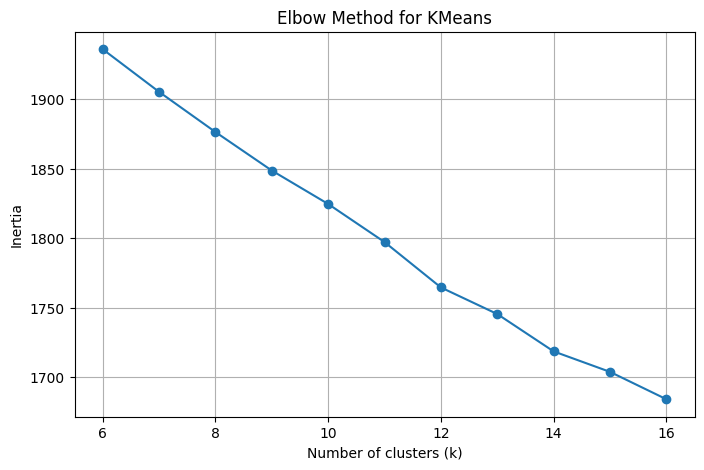

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.grid(True)
plt.show()


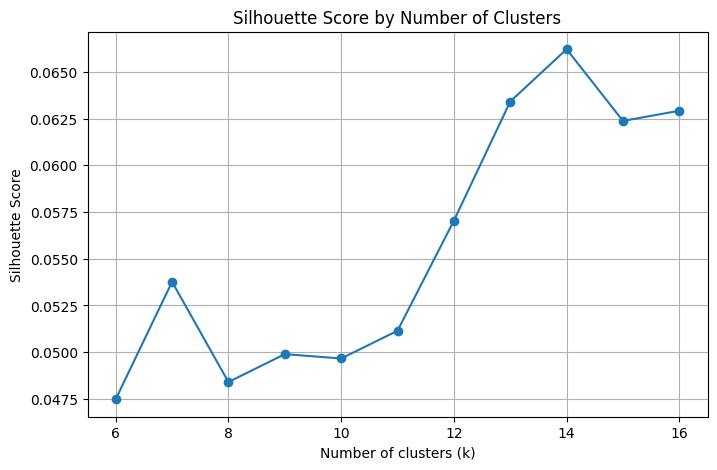

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True)
plt.show()


## Final KMeans Model

Burada raporda ve sunumda açıklaması kolay olması için varsayılan olarak 10 cluster kullanıyoruz.

Grafiklere göre istersen bu değeri değiştirebilirsin.


In [9]:
FINAL_K = 10

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_svd)

print(df["cluster"].value_counts().sort_index())


/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/cluster/_k

cluster
0    5433
1    3099
2     674
3    1437
4     566
5     772
6     755
7    2158
8    6754
9     899
Name: count, dtype: int64


## Top Terms per Cluster

Cluster merkezlerine göre her konu kümesini temsil eden en önemli kelimeleri çıkarıyoruz.


In [10]:
terms = np.array(vectorizer.get_feature_names_out())

# KMeans merkezleri SVD uzayında.
# Yaklaşık yorum için merkezleri tekrar TF-IDF feature uzayına döndürüyoruz.
centers_tfidf_approx = kmeans.cluster_centers_ @ svd.components_

top_terms_rows = []

for cluster_id in range(FINAL_K):
    top_indices = centers_tfidf_approx[cluster_id].argsort()[::-1][:20]
    top_terms = terms[top_indices]

    top_terms_rows.append({
        "cluster": cluster_id,
        "top_terms": ", ".join(top_terms)
    })

top_terms_df = pd.DataFrame(top_terms_rows)
top_terms_df


/var/folders/nz/c0rn9sls69s1plr5bpnbpjg00000gn/T/ipykernel_41744/4030150811.py:5: RuntimeWarning: divide by zero encountered in matmul
  centers_tfidf_approx = kmeans.cluster_centers_ @ svd.components_
/var/folders/nz/c0rn9sls69s1plr5bpnbpjg00000gn/T/ipykernel_41744/4030150811.py:5: RuntimeWarning: overflow encountered in matmul
  centers_tfidf_approx = kmeans.cluster_centers_ @ svd.components_
/var/folders/nz/c0rn9sls69s1plr5bpnbpjg00000gn/T/ipykernel_41744/4030150811.py:5: RuntimeWarning: invalid value encountered in matmul
  centers_tfidf_approx = kmeans.cluster_centers_ @ svd.components_


,cluster,top_terms
0,0,"software, information, systems, web, data, based, research, engineering, software engineering, user, design, science software, engineering computer, systems computer, development, information systems, process, paper, applications, model"
1,1,"architecture, computing, hardware, cloud, performance, hardware architecture, science hardware, architecture computer, security, systems, data, engineering, based, cloud computing, science theory, theory methods, theory, software, time, methods"
2,2,"science library, library science, information science, library, information, business, technology, science information, systems information, information systems, research, information technology, acceptance, systems, management, perceived, model,..."
3,3,"logic, language, semantics, verification, theory, languages, checking, model, programs, programming, formal, systems, automata, theory methods, science theory, logic computer, software, methods, model checking, calculus"
4,4,"operations research, research management, management science, operations, management, research, science operations, optimization, science computer, engineering operations, problem, problems, programming, algorithm, science mathematics, mathematic..."
5,5,"biology, computational biology, mathematical computational, mathematical, computational, molecular, gene, molecular biology, protein, biochemistry, biochemistry molecular, biochemical, biochemical research, research methods, biology biochemistry,..."
6,6,"sensor, sensor networks, wireless, wireless sensor, networks, energy, nodes, network, telecommunications, wsns, sensor network, node, lifetime, telecommunications computer, sensors, sensor nodes, wsn, data, routing, protocol"
7,7,"telecommunications, networks, network, wireless, engineering telecommunications, engineering, electronic telecommunications, channel, electrical, engineering electrical, electrical electronic, electronic, telecommunications computer, systems, tel..."
8,8,"algorithm, artificial, algorithms, intelligence, based, artificial intelligence, science artificial, method, methods, problem, proposed, intelligence computer, image, optimization, data, model, using, neural, paper, theory"
9,9,"finite, element, method, finite element, numerical, interdisciplinary applications, interdisciplinary, equations, flow, applications, mechanics, engineering, multidisciplinary, mathematics, science interdisciplinary, model, boundary, fluid, eleme..."


## Cluster Summary

Her cluster için:

- Makale sayısı
- En sık journal'lar
- En sık subject alanları
- Temsilci kelimeler

çıkarıyoruz.


In [11]:
def top_values(series, n=5):
    return "; ".join([f"{idx} ({cnt})" for idx, cnt in series.value_counts().head(n).items()])

cluster_summaries = []

for cluster_id in sorted(df["cluster"].unique()):
    cluster_df = df[df["cluster"] == cluster_id]

    cluster_summaries.append({
        "cluster": cluster_id,
        "article_count": len(cluster_df),
        "top_journals": top_values(cluster_df["journal_name"], 5),
        "top_subjects": top_values(cluster_df["subjects"], 5),
        "top_terms": top_terms_df.loc[top_terms_df["cluster"] == cluster_id, "top_terms"].iloc[0]
    })

cluster_summary_df = pd.DataFrame(cluster_summaries)
cluster_summary_df


,cluster,article_count,top_journals,top_subjects,top_terms
0,0,5433,USER MODELING AND USER-ADAPTED INTERACTION (75); HUMAN-COMPUTER INTERACTION (73); COMPUTER APPLICATIONS IN ENGINEERING EDUCATION (71); INTERACTING WITH COMPUTERS (68); COMPUTERS & EDUCATION (67),"Computer Science, Software Engineering; Computer Science (933); Computer Science, Information Systems; Computer Science, Software Engineering; Computer Science (548); Computer Science, Information Systems; Computer Science (514); Computer Science...","software, information, systems, web, data, based, research, engineering, software engineering, user, design, science software, engineering computer, systems computer, development, information systems, process, paper, applications, model"
1,1,3099,INTEGRATION-THE VLSI JOURNAL (74); ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECTRONIC SYSTEMS (74); MICROPROCESSORS AND MICROSYSTEMS (68); INTERNATIONAL JOURNAL OF HIGH PERFORMANCE COMPUTING APPLICATIONS (68); ACM TRANSACTIONS ON COMPUTER SYSTEM...,"Computer Science, Hardware & Architecture; Computer Science, Software Engineering; Computer Science (394); Computer Science, Theory & Methods; Computer Science (387); Computer Science, Hardware & Architecture; Computer Science, Theory & Methods; ...","architecture, computing, hardware, cloud, performance, hardware architecture, science hardware, architecture computer, security, systems, data, engineering, based, cloud computing, science theory, theory methods, theory, software, time, methods"
2,2,674,ONLINE INFORMATION REVIEW (76); JOURNAL OF MANAGEMENT INFORMATION SYSTEMS (76); JOURNAL OF STRATEGIC INFORMATION SYSTEMS (75); JOURNAL OF INFORMATION TECHNOLOGY (74); EUROPEAN JOURNAL OF INFORMATION SYSTEMS (69),"Computer Science, Information Systems; Information Science & Library Science; Management; Computer Science; Information Science & Library Science; Business & Economics (261); Computer Science, Information Systems; Information Science & Library Sc...","science library, library science, information science, library, information, business, technology, science information, systems information, information systems, research, information technology, acceptance, systems, management, perceived, model,..."
3,3,1437,JOURNAL OF LOGIC AND COMPUTATION (75); FORMAL METHODS IN SYSTEM DESIGN (72); THEORY AND PRACTICE OF LOGIC PROGRAMMING (70); JOURNAL OF FUNCTIONAL PROGRAMMING (67); ACM TRANSACTIONS ON PROGRAMMING LANGUAGES AND SYSTEMS (61),"Computer Science, Software Engineering; Computer Science (377); Computer Science, Theory & Methods; Logic; Computer Science; Science & Technology - Other Topics (198); Computer Science, Theory & Methods; Computer Science (195); Computer Science, ...","logic, language, semantics, verification, theory, languages, checking, model, programs, programming, formal, systems, automata, theory methods, science theory, logic computer, software, methods, model checking, calculus"
4,4,566,COMPUTERS & OPERATIONS RESEARCH (76); INFORMS JOURNAL ON COMPUTING (76); NETWORKS (75); OPTIMIZATION METHODS & SOFTWARE (74); MATHEMATICAL PROGRAMMING (72),"Computer Science, Software Engineering; Operations Research & Management Science; Mathematics, Applied; Computer Science; Operations Research & Management Science; Mathematics (146); Computer Science, Interdisciplinary Applications; Engineering, ...","operations research, research management, management science, operations, management, research, science operations, optimization, science computer, engineering operations, problem, problems, programming, algorithm, science mathematics, mathematic..."
5,5,772,JOURNAL OF MOLECULAR GRAPHICS & MODELLING (75); COMPUTERS IN BIOLOGY AND MEDICINE (75); BMC BIOINFORMATICS (73); BRIEFINGS IN BIOINFORMATICS (59); EVOLUTIONARY BIOINFORMATICS (56),Mathematical & Computational Biology; Mathematical & Computational Biology (106); Biochemical Research Methods; Mathematical & Computational Biology; Biochemistry & Molecular Biology; Mathematical & Com

## Representative Articles

Her cluster için merkeze en yakın birkaç makaleyi seçiyoruz.


In [12]:
distances = kmeans.transform(X_svd)

representative_rows = []

for cluster_id in range(FINAL_K):
    cluster_indices = np.where(df["cluster"].values == cluster_id)[0]
    cluster_distances = distances[cluster_indices, cluster_id]

    nearest_indices = cluster_indices[np.argsort(cluster_distances)[:5]]

    for rank, idx in enumerate(nearest_indices, start=1):
        representative_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "title": df.iloc[idx]["title"],
            "journal_name": df.iloc[idx]["journal_name"],
            "subjects": df.iloc[idx]["subjects"]
        })

representative_df = pd.DataFrame(representative_rows)
representative_df.head(30)


/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alp/dev/journal-finder-project/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,cluster,rank,title,journal_name,subjects
0,0,1,An empirical study of software piracy and moral intensity among university students,JOURNAL OF COMPUTER INFORMATION SYSTEMS,"Computer Science, Information Systems; Computer Science"
1,0,2,"The perception of accessibility in Web development by academy, industry and government: a survey of the Brazilian scenario",NEW REVIEW OF HYPERMEDIA AND MULTIMEDIA,"Computer Science, Information Systems; Computer Science"
2,0,3,Artefactual Multiplicity: A Study of Emergency-Department Whiteboards,COMPUTER SUPPORTED COOPERATIVE WORK-THE JOURNAL OF COLLABORATIVE COMPUTING,"Computer Science, Interdisciplinary Applications; Computer Science"
3,0,4,Systems science serves enterprise integration: a tutorial,ENTERPRISE INFORMATION SYSTEMS,"Computer Science, Information Systems; Computer Science"
4,0,5,Modeling spreadsheet audit: A rigorous approach to automatic visualization,JOURNAL OF VISUAL LANGUAGES AND COMPUTING,"Computer Science, Software Engineering; Computer Science"
5,1,1,Efficient Hybrid Inline and Out-of-Line Deduplication for Backup Storage,ACM TRANSACTIONS ON STORAGE,"Computer Science, Hardware & Architecture; Computer Science, Software Engineering; Computer Science"
6,1,2,"Heterogeneity in ""Homogeneous"" Warehouse-Scale Computers: A Performance Opportunity",IEEE COMPUTER ARCHITECTURE LETTERS,"Computer Science, Hardware & Architecture; Computer Science"
7,1,3,Amdahl's law revisited for single chip systems,INTERNATIONAL JOURNAL OF PARALLEL PROGRAMMING,"Computer Science, Theory & Methods; Computer Science"
8,1,4,An inverse kinematics architecture enforcing an arbitrary number of strict priority levels,VISUAL COMPUTER,"Computer Science, Software Engineering; Computer Science"
9,1,5,Fast and Portable Locking for Multicore Architectures,ACM TRANSACTIONS ON COMPUTER SYSTEMS,"Computer Science, Theory & Methods; Computer Science"


## Give Human-Readable Cluster Names

Top terms ve subject dağılımına bakarak clusterlara anlaşılır isimler veriyoruz.

İstersen bu isimleri raporda daha akademik hale getirebiliriz.


In [13]:
cluster_names = {}

for _, row in cluster_summary_df.iterrows():
    cluster_id = int(row["cluster"])
    terms_text = row["top_terms"].lower()

    if any(word in terms_text for word in ["image", "video", "visual", "graphics", "segmentation"]):
        name = "Computer Vision and Graphics"
    elif any(word in terms_text for word in ["network", "wireless", "routing", "sensor", "communication"]):
        name = "Networks and Communications"
    elif any(word in terms_text for word in ["software", "requirements", "testing", "maintenance"]):
        name = "Software Engineering"
    elif any(word in terms_text for word in ["database", "query", "retrieval", "information retrieval"]):
        name = "Databases and Information Retrieval"
    elif any(word in terms_text for word in ["security", "privacy", "cryptography", "attack"]):
        name = "Security and Cryptography"
    elif any(word in terms_text for word in ["algorithm", "graph", "optimization", "complexity"]):
        name = "Algorithms and Optimization"
    elif any(word in terms_text for word in ["learning", "neural", "classification", "machine"]):
        name = "Artificial Intelligence and Machine Learning"
    elif any(word in terms_text for word in ["simulation", "modeling", "numerical"]):
        name = "Modeling and Simulation"
    elif any(word in terms_text for word in ["hardware", "architecture", "embedded", "processor"]):
        name = "Computer Architecture and Embedded Systems"
    else:
        name = "General Computer Science Topics"

    cluster_names[cluster_id] = name

cluster_summary_df["cluster_name"] = cluster_summary_df["cluster"].map(cluster_names)

cluster_summary_df = cluster_summary_df[
    ["cluster", "cluster_name", "article_count", "top_terms", "top_journals", "top_subjects"]
]

cluster_summary_df


,cluster,cluster_name,article_count,top_terms,top_journals,top_subjects
0,0,Software Engineering,5433,"software, information, systems, web, data, based, research, engineering, software engineering, user, design, science software, engineering computer, systems computer, development, information systems, process, paper, applications, model",USER MODELING AND USER-ADAPTED INTERACTION (75); HUMAN-COMPUTER INTERACTION (73); COMPUTER APPLICATIONS IN ENGINEERING EDUCATION (71); INTERACTING WITH COMPUTERS (68); COMPUTERS & EDUCATION (67),"Computer Science, Software Engineering; Computer Science (933); Computer Science, Information Systems; Computer Science, Software Engineering; Computer Science (548); Computer Science, Information Systems; Computer Science (514); Computer Science..."
1,1,Software Engineering,3099,"architecture, computing, hardware, cloud, performance, hardware architecture, science hardware, architecture computer, security, systems, data, engineering, based, cloud computing, science theory, theory methods, theory, software, time, methods",INTEGRATION-THE VLSI JOURNAL (74); ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECTRONIC SYSTEMS (74); MICROPROCESSORS AND MICROSYSTEMS (68); INTERNATIONAL JOURNAL OF HIGH PERFORMANCE COMPUTING APPLICATIONS (68); ACM TRANSACTIONS ON COMPUTER SYSTEM...,"Computer Science, Hardware & Architecture; Computer Science, Software Engineering; Computer Science (394); Computer Science, Theory & Methods; Computer Science (387); Computer Science, Hardware & Architecture; Computer Science, Theory & Methods; ..."
2,2,General Computer Science Topics,674,"science library, library science, information science, library, information, business, technology, science information, systems information, information systems, research, information technology, acceptance, systems, management, perceived, model,...",ONLINE INFORMATION REVIEW (76); JOURNAL OF MANAGEMENT INFORMATION SYSTEMS (76); JOURNAL OF STRATEGIC INFORMATION SYSTEMS (75); JOURNAL OF INFORMATION TECHNOLOGY (74); EUROPEAN JOURNAL OF INFORMATION SYSTEMS (69),"Computer Science, Information Systems; Information Science & Library Science; Management; Computer Science; Information Science & Library Science; Business & Economics (261); Computer Science, Information Systems; Information Science & Library Sc..."
3,3,Software Engineering,1437,"logic, language, semantics, verification, theory, languages, checking, model, programs, programming, formal, systems, automata, theory methods, science theory, logic computer, software, methods, model checking, calculus",JOURNAL OF LOGIC AND COMPUTATION (75); FORMAL METHODS IN SYSTEM DESIGN (72); THEORY AND PRACTICE OF LOGIC PROGRAMMING (70); JOURNAL OF FUNCTIONAL PROGRAMMING (67); ACM TRANSACTIONS ON PROGRAMMING LANGUAGES AND SYSTEMS (61),"Computer Science, Software Engineering; Computer Science (377); Computer Science, Theory & Methods; Logic; Computer Science; Science & Technology - Other Topics (198); Computer Science, Theory & Methods; Computer Science (195); Computer Science, ..."
4,4,Algorithms and Optimization,566,"operations research, research management, management science, operations, management, research, science operations, optimization, science computer, engineering operations, problem, problems, programming, algorithm, science mathematics, mathematic...",COMPUTERS & OPERATIONS RESEARCH (76); INFORMS JOURNAL ON COMPUTING (76); NETWORKS (75); OPTIMIZATION METHODS & SOFTWARE (74); MATHEMATICAL PROGRAMMING (72),"Computer Science, Software Engineering; Operations Research & Management Science; Mathematics, Applied; Computer Science; Operations Research & Management Science; Mathematics (146); Computer Science, Interdisciplinary Applications; Engineering, ..."
5,5,General Computer Science Topics,772,"biology, computational biology, mathematical computational, mathematical, computational, molecular, gene, molecular biology, protein, biochemistry, biochemistry molecular, biochemical, biochemical research, resear

## Save Clustering Outputs

In [14]:
clustered_data_path = REPORT_DATA_DIR / "clustered_articles.csv"
cluster_summary_path = REPORT_DATA_DIR / "cluster_summary.csv"
representative_articles_path = REPORT_DATA_DIR / "cluster_representative_articles.csv"

df.to_csv(clustered_data_path, index=False)
cluster_summary_df.to_csv(cluster_summary_path, index=False)
representative_df.to_csv(representative_articles_path, index=False)

joblib.dump(vectorizer, OUTPUT_DIR / "topic_vectorizer.pkl")
joblib.dump(svd, OUTPUT_DIR / "topic_svd.pkl")
joblib.dump(kmeans, OUTPUT_DIR / "topic_kmeans.pkl")

metadata = {
    "method": "TF-IDF + TruncatedSVD + KMeans",
    "n_components": N_COMPONENTS,
    "final_k": FINAL_K,
    "rows_used": int(len(df)),
    "tfidf_shape": list(X_tfidf.shape),
    "svd_explained_variance_ratio": float(explained),
    "cluster_names": {str(k): v for k, v in cluster_names.items()}
}

with open(OUTPUT_DIR / "topic_clustering_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved:", clustered_data_path)
print("Saved:", cluster_summary_path)
print("Saved:", representative_articles_path)
print("Saved clustering models to:", OUTPUT_DIR)


Saved: /Users/alp/dev/journal-finder-project/data/clustered_articles.csv
Saved: /Users/alp/dev/journal-finder-project/data/cluster_summary.csv
Saved: /Users/alp/dev/journal-finder-project/data/cluster_representative_articles.csv
Saved clustering models to: /Users/alp/dev/journal-finder-project/models
